In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve)



In [60]:
lending_data = pd.read_csv("loans_full_schema.csv")
lending_data.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [61]:
bad_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)']
lending_data['default'] = lending_data['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

print(lending_data['default'].value_counts())  # Check imbalance

default
0    9822
1     178
Name: count, dtype: int64


In [62]:

features = [
    'annual_income', 'debt_to_income', 'delinq_2y', 'inquiries_last_12m',
    'total_credit_lines', 'open_credit_lines', 'total_credit_utilized',
    'num_historical_failed_to_pay', 'interest_rate', 'loan_amount'
]
target = 'default'

X = lending_data[features]
y = lending_data[target]


X.fillna(X.median(numeric_only=True), inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



/var/folders/g9/2f4r326x23q5qyx4md2hs3_00000gn/T/ipykernel_49744/2132041765.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(numeric_only=True), inplace=True)


In [63]:

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train, y_train)
y_prob_log = log_reg.predict_proba(X_test)[:,1]


rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:,1]


y_pred_log = (y_prob_log >= 0.5).astype(int)
y_pred_rf = (y_prob_rf >= 0.5).astype(int)


Logistic Regression AUC: 0.752
Random Forest AUC: 0.742

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.99      0.67      0.80      1962
           1       0.04      0.66      0.07        38

    accuracy                           0.67      2000
   macro avg       0.51      0.66      0.44      2000
weighted avg       0.97      0.67      0.79      2000


Random Forest Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.95      1962
           1       0.05      0.24      0.08        38

    accuracy                           0.90      2000
   macro avg       0.52      0.57      0.51      2000
weighted avg       0.97      0.90      0.93      2000



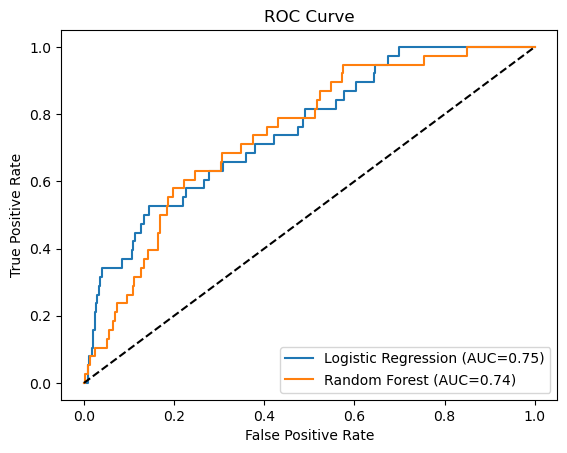

In [64]:

log_auc = roc_auc_score(y_test, y_prob_log)
rf_auc = roc_auc_score(y_test, y_prob_rf)
print(f"Logistic Regression AUC: {log_auc:.3f}")
print(f"Random Forest AUC: {rf_auc:.3f}")


print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))


fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={log_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


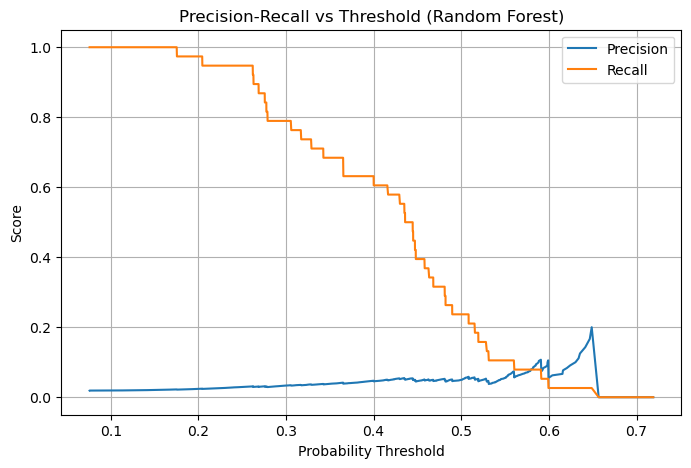

In [65]:

prec, rec, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,5))
plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (Random Forest)')
plt.legend()
plt.grid()
plt.show()


In [66]:


prec, rec, thresholds = precision_recall_curve(y_test, y_prob_rf)


f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)  


best_idx = np.argmax(f1_scores)
threshold_num = thresholds[best_idx]  
best_f1 = f1_scores[best_idx]

print(f"Best Threshold (Max F1): {threshold_num:.3f}")
print(f"F1 Score at Best Threshold: {best_f1:.3f}")
print(f"Precision: {prec[best_idx]:.3f}, Recall: {rec[best_idx]:.3f}")


y_pred_rf_f1 = (y_prob_rf >= threshold_num).astype(int)


print("\nClassification Report (Random Forest - Optimized for F1):")
print(classification_report(y_test, y_pred_rf_f1))


Best Threshold (Max F1): 0.435
F1 Score at Best Threshold: 0.099
Precision: 0.055, Recall: 0.553

Classification Report (Random Forest - Optimized for F1):
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1962
           1       0.05      0.55      0.10        38

    accuracy                           0.81      2000
   macro avg       0.52      0.68      0.50      2000
weighted avg       0.97      0.81      0.88      2000



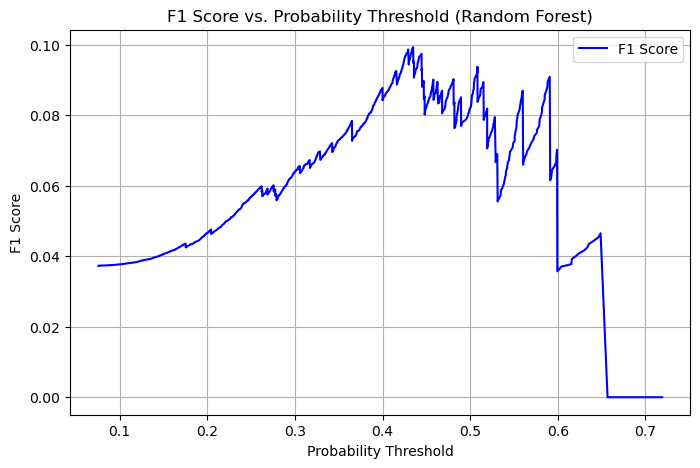

Best F1 Score: 0.099 at Threshold: 0.435


In [67]:


prec, rec, thresholds = precision_recall_curve(y_test, y_prob_rf)


f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)  


plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='blue')
plt.xlabel('Probability Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Probability Threshold (Random Forest)')
plt.grid()
plt.legend()
plt.show()


best_idx = np.argmax(f1_scores)
print(f"Best F1 Score: {f1_scores[best_idx]:.3f} at Threshold: {thresholds[best_idx]:.3f}")


In [68]:

threshold = threshold_num
y_pred_rf_custom = (y_prob_rf >= threshold).astype(int)

print(f"Classification Report (Random Forest, threshold={threshold}):\n")
print(classification_report(y_test, y_pred_rf_custom))


Classification Report (Random Forest, threshold=0.43496544034435985):

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      1962
           1       0.05      0.55      0.10        38

    accuracy                           0.81      2000
   macro avg       0.52      0.68      0.50      2000
weighted avg       0.97      0.81      0.88      2000



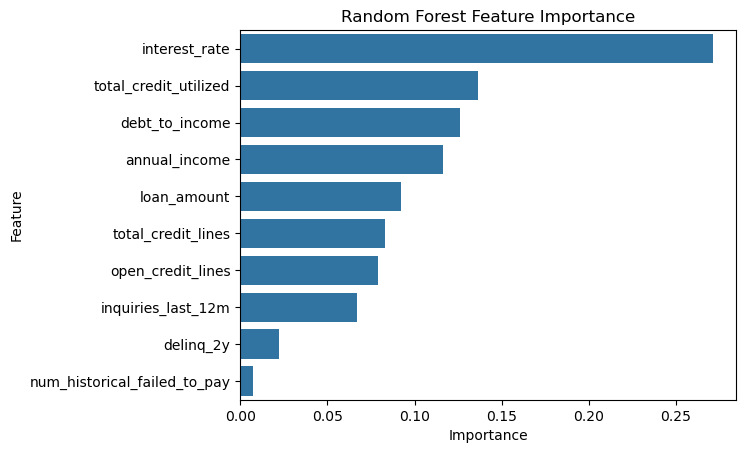

,Feature,Importance
8,interest_rate,0.271057
6,total_credit_utilized,0.136585
1,debt_to_income,0.125819
0,annual_income,0.116281
9,loan_amount,0.092023
4,total_credit_lines,0.082976
5,open_credit_lines,0.079026
3,inquiries_last_12m,0.066913
2,delinq_2y,0.022117
7,num_historical_failed_to_pay,0.007204


In [69]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Random Forest Feature Importance')
plt.show()

feature_importance
